In [1]:
import gwsurrogate

/home/omkarnm1401/miniconda3/envs/ut_codex/lib/python3.11/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
import pandas as pd

In [3]:
from gwtools.gwtools import minimize_norm_error_multi_mode

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
# add the path to the script directory
sys.path.append("/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates")
import BHPTNRSur1dq1e4 as bhptsur

/home/omkarnm1401/UT_Austin/BHPTNRSurrogate/surrogates/../data
**** Surrogate loaded: BHPTNRSur1dq1e4 ****


In [5]:
import matplotlib as mpl

sys.path.append("/home/omkarnm1401/UT_Austin/BHPTutils")
import bhpt_utils
mpl.rcdefaults()

In [6]:
nrsur = gwsurrogate.LoadSurrogate('NRHybSur3dq8')

Loaded NRHybSur3dq8 model


In [7]:
# convience wrapper for calling the NRHybSur3dq8 model
def generate_nrsur(q_input, f_low=None, t_start=None):
    chiA = [0, 0, 0.0]
    chiB = [0, 0, 0.0]
    dt = 0.1        # step size, Units of M
    if f_low==None:
        f_low=5e-3
    if t_start==None:
        t_start=-5000.1
    # dyn stands for dynamics and is always None for this model
    t, h, dyn = nrsur(q_input, chiA, chiB, dt=dt, f_low=f_low) 
    # we only take the last 5000M long waveform to calibrate
    indx = np.where(t>=t_start)
    t = t[indx]
    for mode in h.keys():
        h[mode] = h[mode][indx]
    return t,h

In [8]:
q_input = 1.5
mass_norm = 1/(1+1/q_input)

In [9]:
tnr, h_NRHybSur3dq8 = generate_nrsur(q_input=q_input)

In [10]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhpt, hbhpt = bhptsur.generate_surrogate(q=q_input, modes=h_NRHybSur3dq8.keys(), calibrated=False, neg_modes=False)

**** warning **** : input parameter is outside bounds for paramter value at index 0
**** warning **** : modes are NOT NR calibrated - waveforms only have 0PA contribution


In [11]:
h_NR_22 = h_NRHybSur3dq8[(2, 2)]

In [12]:
import gwtools

In [13]:
def mathcalE_error(h1, h2):
    """
    Compute time-domain waveform error.

    Calculates the normalized L2 error between two waveforms using the metric
    defined in Eq. 21 of https://arxiv.org/pdf/1701.00550.pdf

    Parameters:
    -----------
    h1 : array (complex)
        Reference waveform (used for normalization)
    h2 : array (complex)
        Comparison waveform (same length as h1)

    Returns:
    --------
    normed_errs : float
        Normalized error: (||h1||² + ||h2||² - 2*Re(<h1,h2>)) / (2*||h1||²)
        Value of 0 indicates perfect agreement, larger values indicate greater disagreement

    Notes:
    ------
    - Assumes h1 is the reference waveform and normalizes by its magnitude
    - Both waveforms should have the same time sampling
    - The metric is symmetric in the numerator but asymmetric due to normalization by ||h1||²
    """
    # Compute norms squared
    n1Sqr = np.sum(np.abs(h1)**2)
    n2Sqr = np.sum(np.abs(h2)**2)

    # Compute inner product
    dots = np.array([h1[i] * (h2[i].conjugate()) for i in range(len(h1))])
    sdot = np.real(np.sum(dots))

    # Normalize error by reference waveform magnitude
    normed_errs = ((n1Sqr + n2Sqr) - 2 * sdot) / (2 * n1Sqr)

    return normed_errs

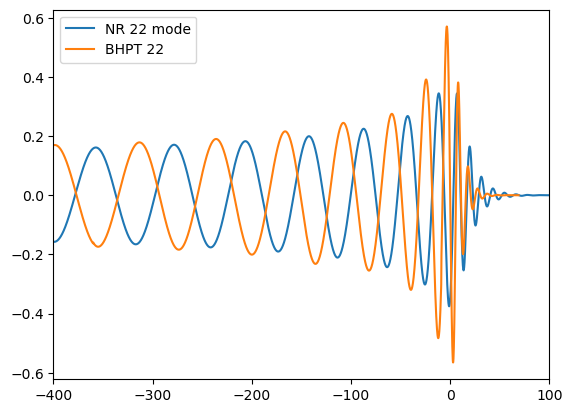

In [14]:
plt.plot(tnr, np.real(h_NR_22), label = 'NR 22 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(2,2)])  * mass_norm, label = 'BHPT 22')

plt.xlim(-400, 100)
plt.legend()

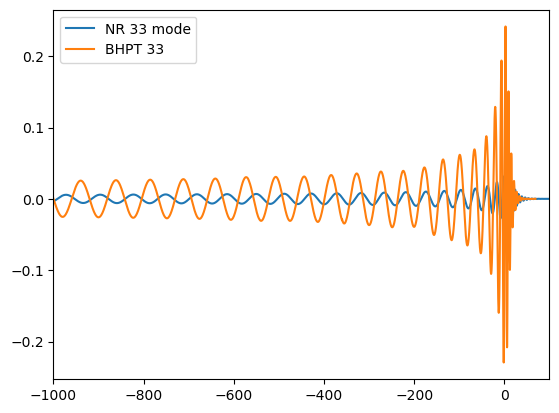

In [15]:
h_nr_33 = h_NRHybSur3dq8[(3, 3)]

plt.plot(tnr, np.real(h_nr_33), label = 'NR 33 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(3,3)])  * mass_norm, label = 'BHPT 33')

plt.xlim(-1000, 100)
plt.legend()

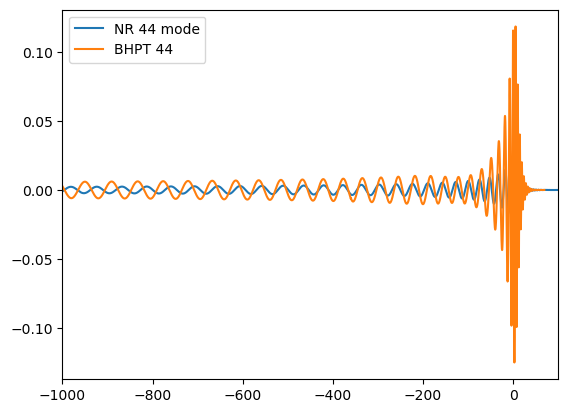

In [16]:
h_nr_44 = h_NRHybSur3dq8[(4, 4)]

plt.plot(tnr, np.real(h_nr_44), label = 'NR 44 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(4, 4)])  * mass_norm, label = 'BHPT 44')

plt.xlim(-1000, 100)
plt.legend()

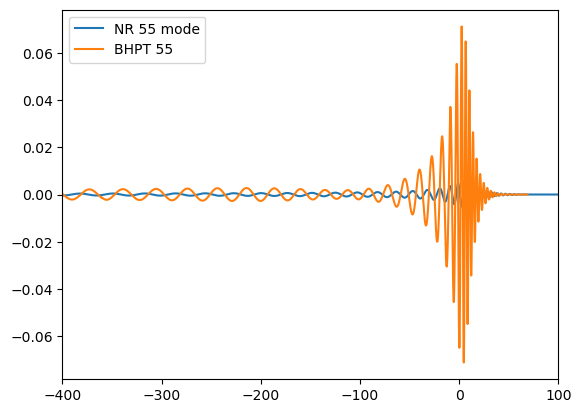

In [17]:
h_nr_55 = h_NRHybSur3dq8[(5, 5)]

plt.plot(tnr, np.real(h_nr_55), label = 'NR 55 mode')
plt.plot(tbhpt  * mass_norm, np.real(hbhpt[(5, 5)])  * mass_norm, label = 'BHPT 55')

plt.xlim(-400, 100)
plt.legend()

In [18]:
h_bhpt_interp = gwtools.interpolate_h(tbhpt * mass_norm, hbhpt[(2,2)], tnr)
mathcalE_error(h_NR_22, h_bhpt_interp)

>>> Warning: Requested samples are outside of interpolated domain.


np.float64(2.875844896958011)

# %load scaling_qdep.md
# q-dependent scaling fit

Fit form:

```python
alpha(q, l) = 1 + A_alpha(l)/q + B_alpha(l)/q**2 + C_alpha(l)/q**3 + D_alpha(l)/q**4
beta(q) = 1 + A_beta/q + B_beta/q**2 + C_beta/q**3 + D_beta/q**4
```

The fit used 40 uniformly spaced q values from 3 to 10 and modes `(l,l)` for `l = 2, 3, 4, 5`. The `mathcalE` definition matches `NRBHP_ansatz.py`. A constant time shift and phase rotation were treated as nuisance alignment parameters when measuring the final errors; they are not included in the alpha/beta ansatz coefficients.

`NRHybSur3dq8` warns that q values above about 8.01 are outside its training range, so the high-q part of this q=3..10 sweep uses NR surrogate extrapolation.

## beta coefficients

| A_beta | B_beta | C_beta | D_beta |
|---:|---:|---:|---:|
| -1.24116450042 | 1.63823509893 | -1.97154177912 | 1.33749010735 |

## alpha coefficients

| l | A_alpha | B_alpha | C_alpha | D_alpha |
|---:|---:|---:|---:|---:|
| 2 | -1.34005326034 | 2.88788867946 | -6.79063043803 | 7.02639406495 |
| 3 | -3.10607054305 | 6.94779267852 | -13.7319640012 | 12.9087168665 |
| 4 | -3.98079244161 | 10.5911609772 | -20.5071088134 | 18.9621851423 |
| 5 | -4.74037229115 | 8.87898607451 | 0.581593859672 | -17.5244928804 |

## achieved errors

| l | min mathcalE | median mathcalE | max mathcalE | q at max |
|---:|---:|---:|---:|---:|
| 2 | 0.00051275989 | 0.0010217173 | 0.0022646289 | 3 |
| 3 | 0.0014174235 | 0.0032100239 | 0.0088387899 | 3 |
| 4 | 0.0054982148 | 0.010743526 | 0.049278533 | 3 |
| 5 | 0.010581142 | 0.018282525 | 0.080872676 | 3 |

## notes

The earlier hard error thresholds were relaxed. The table above reports the achieved errors from the fitted constant-in-time q-dependent ansatz. The higher modes, especially l=4 and l=5 at low q, retain larger errors because a single constant beta(q) and scalar alpha(q,l) cannot fully absorb their residual time-dependent structure over the full `t >= -5000.1` window.


In [19]:
from pathlib import Path
from io import StringIO


def read_markdown_table_after_heading(md_path, heading):
    text = Path(md_path).read_text()

    # Find the requested heading
    start = text.index(heading)
    section = text[start:]

    # Find the first markdown table after that heading
    lines = section.splitlines()

    table_lines = []
    in_table = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("|") and stripped.endswith("|"):
            table_lines.append(stripped)
            in_table = True
        elif in_table:
            break

    if not table_lines:
        raise ValueError(f"No markdown table found after heading: {heading}")

    # Remove markdown alignment row, e.g. |---:|---:|
    table_lines = [
        line for line in table_lines
        if not all(cell.strip().replace(":", "").replace("-", "") == ""
                   for cell in line.strip("|").split("|"))
    ]

    csv_text = "\n".join(
        ",".join(cell.strip() for cell in line.strip("|").split("|"))
        for line in table_lines
    )

    return pd.read_csv(StringIO(csv_text))

In [20]:
alpha_df = read_markdown_table_after_heading(
    "scaling_qdep.md",
    "## alpha coefficients"
)

alpha_df

,l,A_alpha,B_alpha,C_alpha,D_alpha
0,2,-1.340053,2.887889,-6.790630,7.026394
1,3,-3.106071,6.947793,-13.731964,12.908717
2,4,-3.980792,10.591161,-20.507109,18.962185
3,5,-4.740372,8.878986,0.581594,-17.524493


In [21]:
alpha_coeffs = alpha_df.set_index("l")

def alpha_fac(q, l):
    c = alpha_coeffs.loc[l]
    return (
        1
        + c["A_alpha"] / q
        + c["B_alpha"] / q**2
        + c["C_alpha"] / q**3
        + c["D_alpha"] / q**4
    )

In [22]:
beta_df = read_markdown_table_after_heading(
    "scaling_qdep.md",
    "## beta coefficients"
)

beta_df

,A_beta,B_beta,C_beta,D_beta
0,-1.241165,1.638235,-1.971542,1.33749


In [23]:
beta_coeffs = beta_df.iloc[0]

def beta_fac(q):
    c = beta_coeffs
    return (
        1
        + c["A_beta"] / q
        + c["B_beta"] / q**2
        + c["C_beta"] / q**3
        + c["D_beta"] / q**4
    )

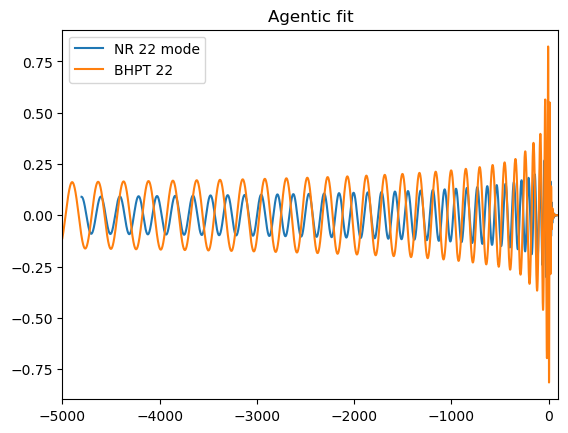

In [24]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
plt.plot((tbhpt)  * beta_fac(8), np.real(hbhpt[(2, 2)])  * alpha_fac(8, 2), label = 'BHPT 22')

plt.xlim(-5000, 100)
plt.title('Agentic fit')

plt.legend()
plt.show()

In [25]:
mode_list = [
    mode for mode in hbhpt.keys()
    if mode[0] in [2, 3, 4, 5]
]

# Apply beta time rescaling.
# Use tbhpt / beta_fac(q) if your intended calibration is h_cal(t) = h_raw(beta * t)


# Apply alpha_l amplitude rescaling mode-by-mode
hbhpt_extcal = {
    mode: alpha_fac(q_input, mode[0]) * hbhpt[mode]
    for mode in mode_list
}

[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode((tbhpt)  * beta_fac(q_input),  hbhpt_extcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

Performing a physical rotation by pi...


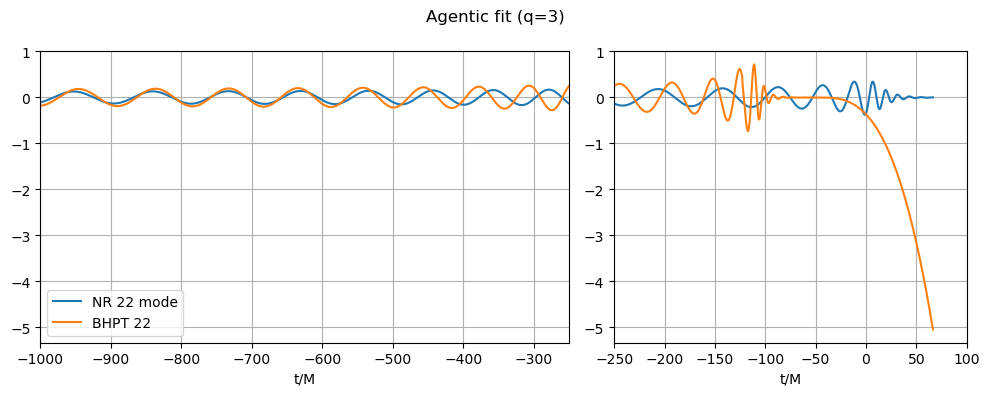

In [26]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax1.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
ax2.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

plt.suptitle('Agentic fit (q=3)')


plt.tight_layout()
plt.show()

In [27]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.4572654689832622)

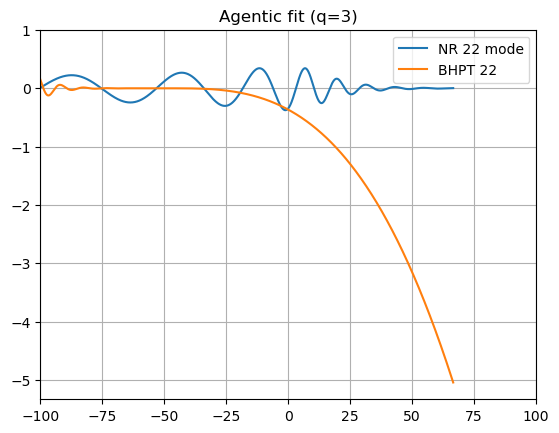

In [28]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]

plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode')
plt.plot(common_times, np.real(h_bhpt_aligned[(2, 2)]), label = 'BHPT 22')

plt.xlim(-100, 100)
plt.title('Agentic fit (q=3)')

plt.grid(True)
plt.legend()
plt.show()

In [29]:
modes = [(2,2)]
ab = bhpt_utils.all_alpha_beta_1D_scaling_params(q_input, modes)
print(ab)

{'beta': 0.5665856983804294, 'alpha_l2m2': 0.6688194828625675}


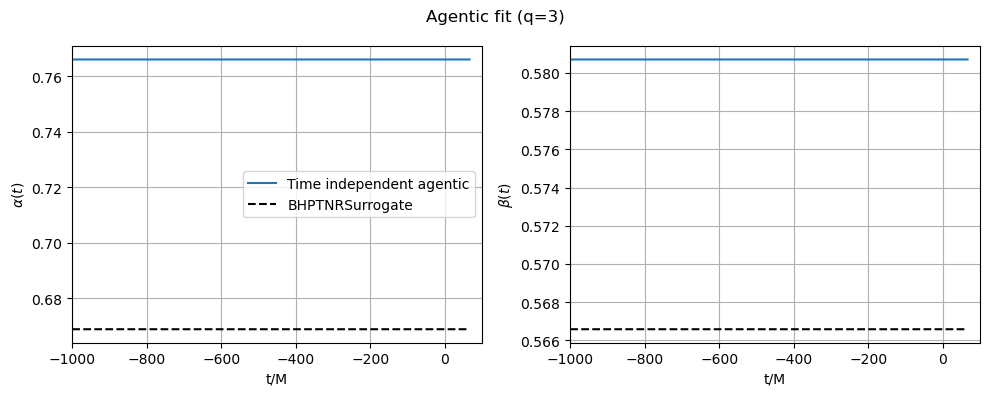

In [30]:
h_nr_22 = h_NRHybSur3dq8[(2, 2)]
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [2, 2]}
)


tbhpt_extcal = (tbhpt)  * beta_fac(q_input)
#ax1.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * alpha_fac(q_input, 2), label = 'Time independent agentic')
ax1.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['alpha_l2m2'], label = 'BHPTNRSurrogate', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, 100)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.set_ylabel(r'$\alpha(t)$')
ax1.legend()

#ax2.plot(tnr, np.real(h_nr_22), label = 'NR 22 mode')
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * beta_fac(q_input))
ax2.plot(tbhpt_extcal, np.ones(len(tbhpt_extcal)) * ab['beta'], linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')
ax2.set_ylabel(r'$\beta(t)$')

ax2.set_xlim(-1000, 100)
ax2.grid(True)

plt.suptitle('Agentic fit (q=3)')


plt.tight_layout()
#plt.savefig(plot_dir + 'Stricter_agentic_fit_params.pdf')
plt.show()

In [31]:
nr_modes = list(h_NRHybSur3dq8.keys())
for mode in nr_modes:
    if mode[1] <=0: # m<=0; remove the (2,0) and (3,0) modes from NRHybSur3dq8 (these are not included in the BHPTNRSur1dq1e4 model)
        h_NRHybSur3dq8.pop(mode)
        
tbhptcal, hbhptcal = bhptsur.generate_surrogate(q=q_input, modes=h_NRHybSur3dq8.keys(), calibrated=True, neg_modes=False)

**** warning **** : input parameter is outside bounds for paramter value at index 0


In [32]:
[errors_before_min, errors_after_min], [tc, phic], [common_times,h_bhpt_aligned,h_nr_aligned] = \
                            minimize_norm_error_multi_mode(tbhptcal, hbhptcal, tnr, h_NRHybSur3dq8, mode_list=None, ell_m_match=(2,2),\
                                    t_low_adj=0,t_up_adj=0,method='nelder-mead')

Performing a physical rotation by pi...


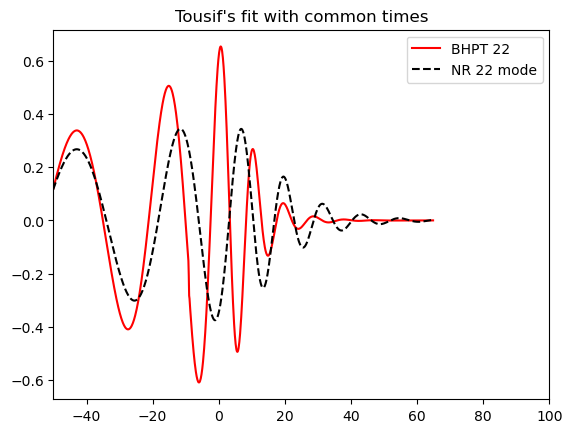

In [33]:
plt.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
plt.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')

plt.xlim(-50, 100)
plt.legend()

plt.title("Tousif's fit with common times")
plt.show()

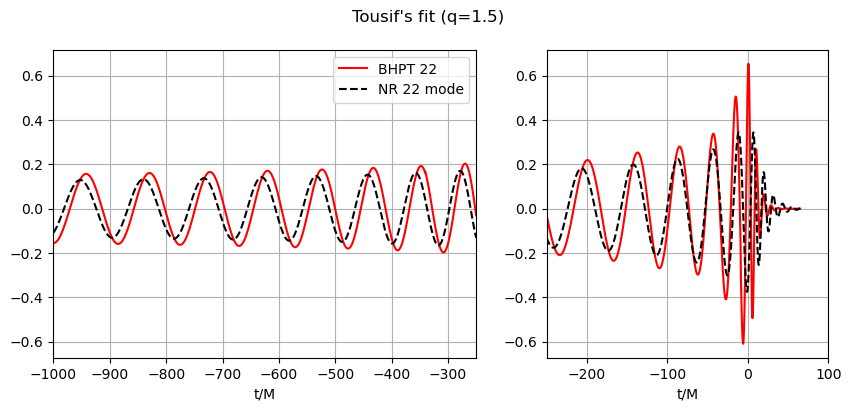

In [34]:
fig, (ax1, ax2) = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 4), 
    gridspec_kw={'width_ratios': [3, 2]}
)



ax1.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
ax1.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')

ax1.set_xlim(-1000, -250)
ax1.grid(True)
ax1.set_xlabel('t/M')
ax1.legend()

ax2.plot(common_times, np.real(h_bhpt_aligned[(2,2)]), label = 'BHPT 22', color = 'red')
ax2.plot(common_times, np.real(h_nr_aligned[(2,2)]), label = 'NR 22 mode', linestyle = 'dashed', color = 'k')
ax2.set_xlabel('t/M')

ax2.set_xlim(-250, 100)
ax2.grid(True)

#plt.tight_layout()
plt.suptitle(f"Tousif's fit (q={q_input})")
plt.show()

In [35]:
mathcalE_error(h_bhpt_aligned[(2,2)], h_nr_aligned[(2,2)])

np.float64(0.23088626262339257)